In [1]:
import sys
from pathlib import Path

# Allow notebook to import project modules
sys.path.append(str(Path.cwd().parent))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ingestion.folder_scanner import scan_folder

images = scan_folder()

print(f"Images found: {len(images)}")

Images found: 200


In [4]:
from ingestion.image_pairer import pair_images

pairs = pair_images(images)

print(f"Pairs found: {len(pairs)}")

Pairs found: 100


In [5]:
import pandas as pd

rows = []

for i, (front, back) in enumerate(pairs, start=1):
    rows.append({
        "Pair": i,
        "Front": front.name,
        "Back": back.name
    })

df = pd.DataFrame(rows)

df

,Pair,Front,Back
0,1,IMG_20260716_055945_060.jpg,IMG_20260716_055957_877.jpg
1,2,IMG_20260716_060011_494.jpg,IMG_20260716_060025_512.jpg
2,3,IMG_20260716_060040_364.jpg,IMG_20260716_060055_627.jpg
3,4,IMG_20260716_060112_485.jpg,IMG_20260716_060121_908.jpg
4,5,IMG_20260716_060134_232.jpg,IMG_20260716_060144_848.jpg
...,...,...,...
95,96,IMG_20260716_062628_603.jpg,IMG_20260716_062634_475.jpg
96,97,IMG_20260716_062641_359.jpg,IMG_20260716_062646_108.jpg
97,98,IMG_20260716_062652_676.jpg,IMG_20260716_062657_724.jpg
98,99,IMG_20260716_062703_991.jpg,IMG_20260716_062709_288.jpg


## Pair 1

Front


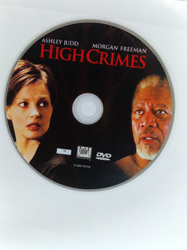

Back


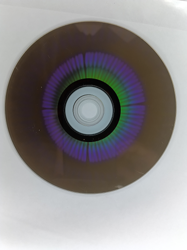

--------------------------------------------------------------------------------


## Pair 2

Front


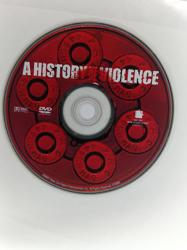

Back


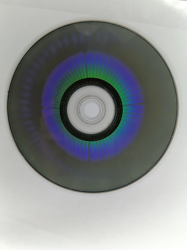

--------------------------------------------------------------------------------


## Pair 3

Front


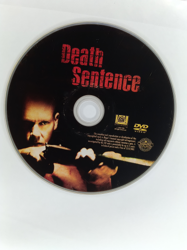

Back


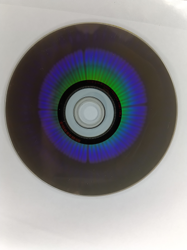

--------------------------------------------------------------------------------


## Pair 4

Front


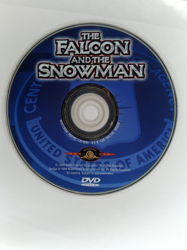

Back


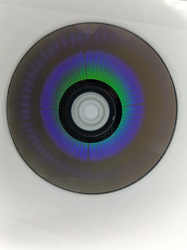

--------------------------------------------------------------------------------


## Pair 5

Front


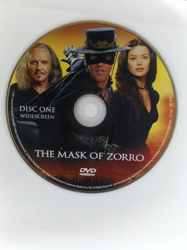

Back


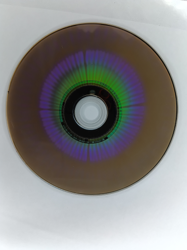

--------------------------------------------------------------------------------


In [7]:
from IPython.display import display, Markdown
from processing.processors.thumbnail_processor import create_thumbnail_pair

# Preview the first 5 pairs
for i in range(min(5, len(pairs))):

    display(Markdown(f"## Pair {i+1}"))

    front, back = create_thumbnail_pair(
        pairs[i][0],
        pairs[i][1]
    )

    print("Front")
    display(front)

    print("Back")
    display(back)

    print("-" * 80)

In [10]:
import pandas as pd
from IPython.display import HTML
from pathlib import Path

rows = []

for i, (front, back) in enumerate(pairs[:10], start=1):

    front_path = Path(front).resolve().as_posix()
    back_path = Path(back).resolve().as_posix()

    rows.append({
        "Pair": i,
        "Front":
            f'<a href="file:///{front_path}" target="_blank">'
            f'<img src="file:///{front_path}" width="150"></a>',
        "Back":
            f'<a href="file:///{back_path}" target="_blank">'
            f'<img src="file:///{back_path}" width="150"></a>',
        "Storage Case": "",
        "GUID": "",
        "Status": "Pending"
    })

review_df = pd.DataFrame(rows)

HTML(review_df.to_html(escape=False, index=False))

Pair,Front,Back,Storage Case,GUID,Status
1,,,,,Pending
2,,,,,Pending
3,,,,,Pending
4,,,,,Pending
5,,,,,Pending
6,,,,,Pending
7,,,,,Pending
8,,,,,Pending
9,,,,,Pending
10,,,,,Pending
